In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv(r'D:\DL\27th  Feb - TIme Series\AirPassengers.csv')

In [5]:
data.head(5)

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [11]:
data.columns = ['Date','Number of Passengers']

In [12]:
data.head(5)

,Date,Number of Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


## Visulazing The Data

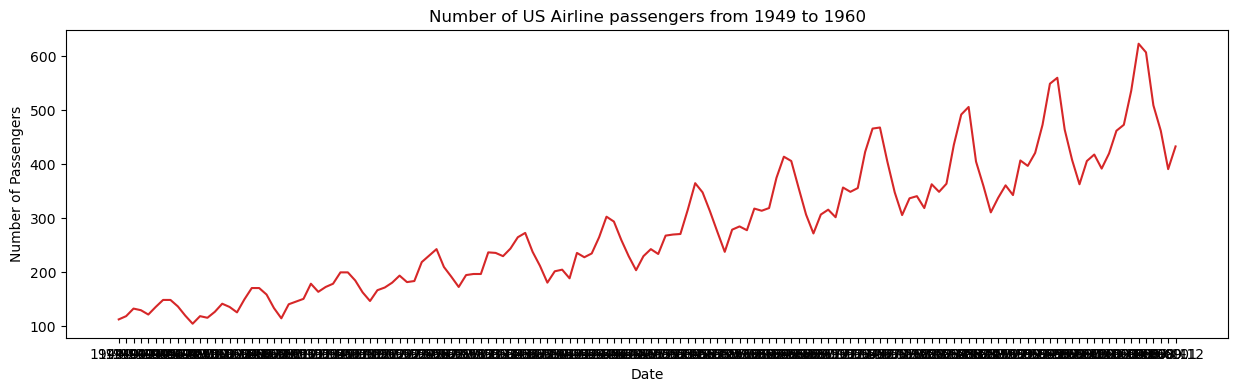

In [13]:
def plot_data(data, x, y, title="", xlabel='Date', ylabel='Number of Passengers', dpi=100):
    plt.figure(figsize=(15,4), dpi=dpi)
    plt.plot(x, y, color='tab:red')
    plt.gca().set(title=title, xlabel=xlabel, ylabel=ylabel)
    plt.show()
    

plot_data(data, x=data['Date'], y=data['Number of Passengers'], title='Number of US Airline passengers from 1949 to 1960')

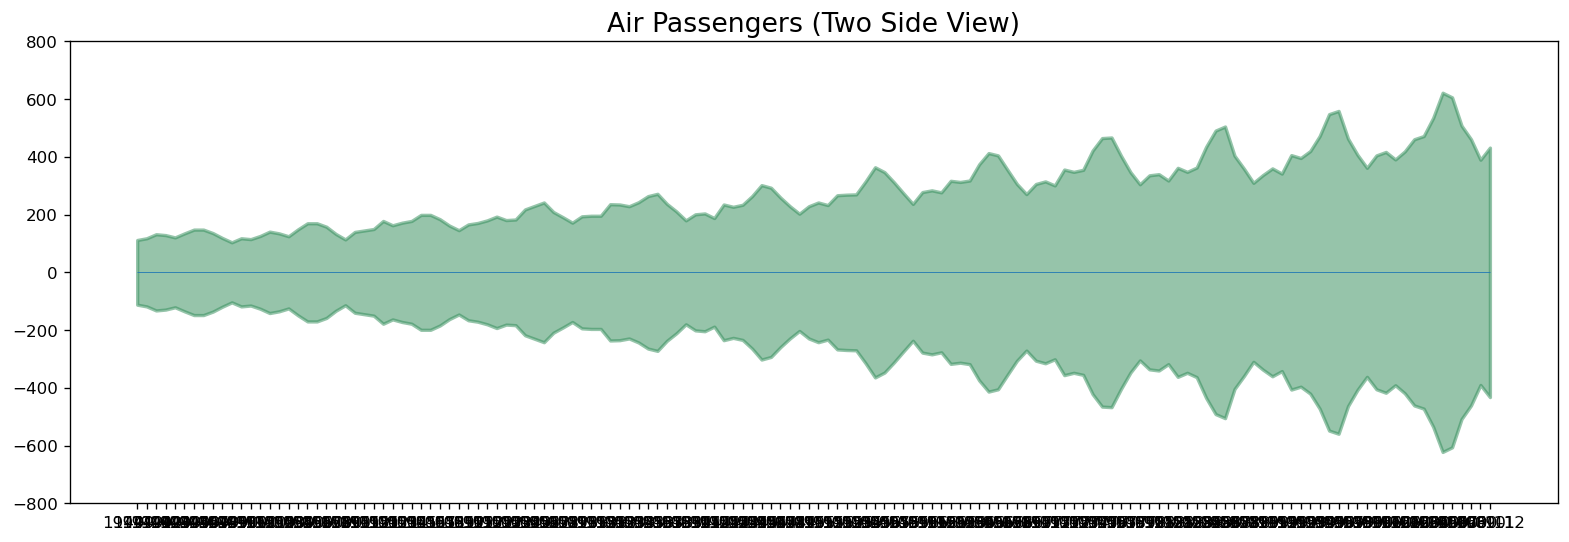

In [14]:
x = data['Date'].values
y1 = data['Number of Passengers'].values

# Plot
fig, ax = plt.subplots(1, 1, figsize=(16,5), dpi= 120)
plt.fill_between(x, y1=y1, y2=-y1, alpha=0.5, linewidth=2, color='seagreen')
plt.ylim(-800, 800)
plt.title('Air Passengers (Two Side View)', fontsize=16)
plt.hlines(y=0, xmin=np.min(data['Date']), xmax=np.max(data['Date']), linewidth=.5)
plt.show()

## Patterns In Time Series

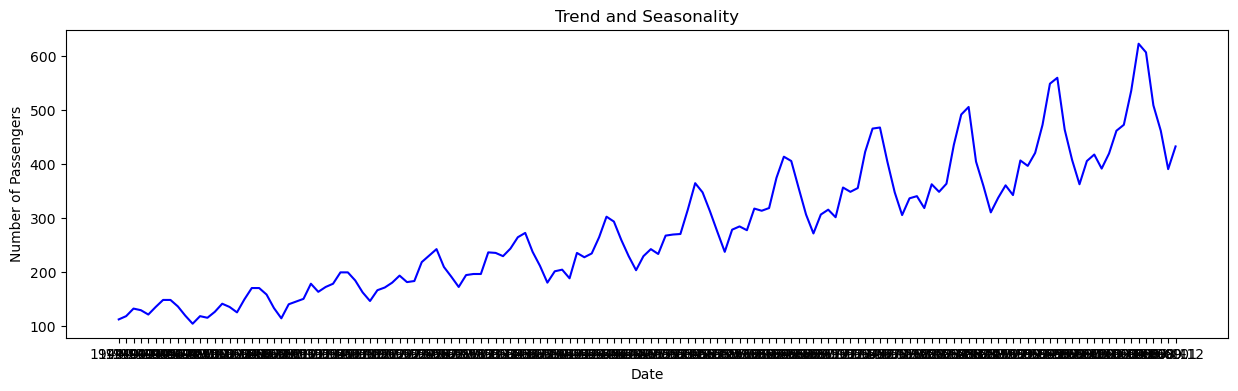

In [15]:
def plot_data(data, x, y, title="", xlabel='Date', ylabel='Number of Passengers', dpi=100):
    plt.figure(figsize=(15,4), dpi=dpi)
    plt.plot(x, y, color='blue')
    plt.gca().set(title=title, xlabel=xlabel, ylabel=ylabel)
    plt.show()
    
plot_data(data, x=data['Date'], y=data['Number of Passengers'], title='Trend and Seasonality')

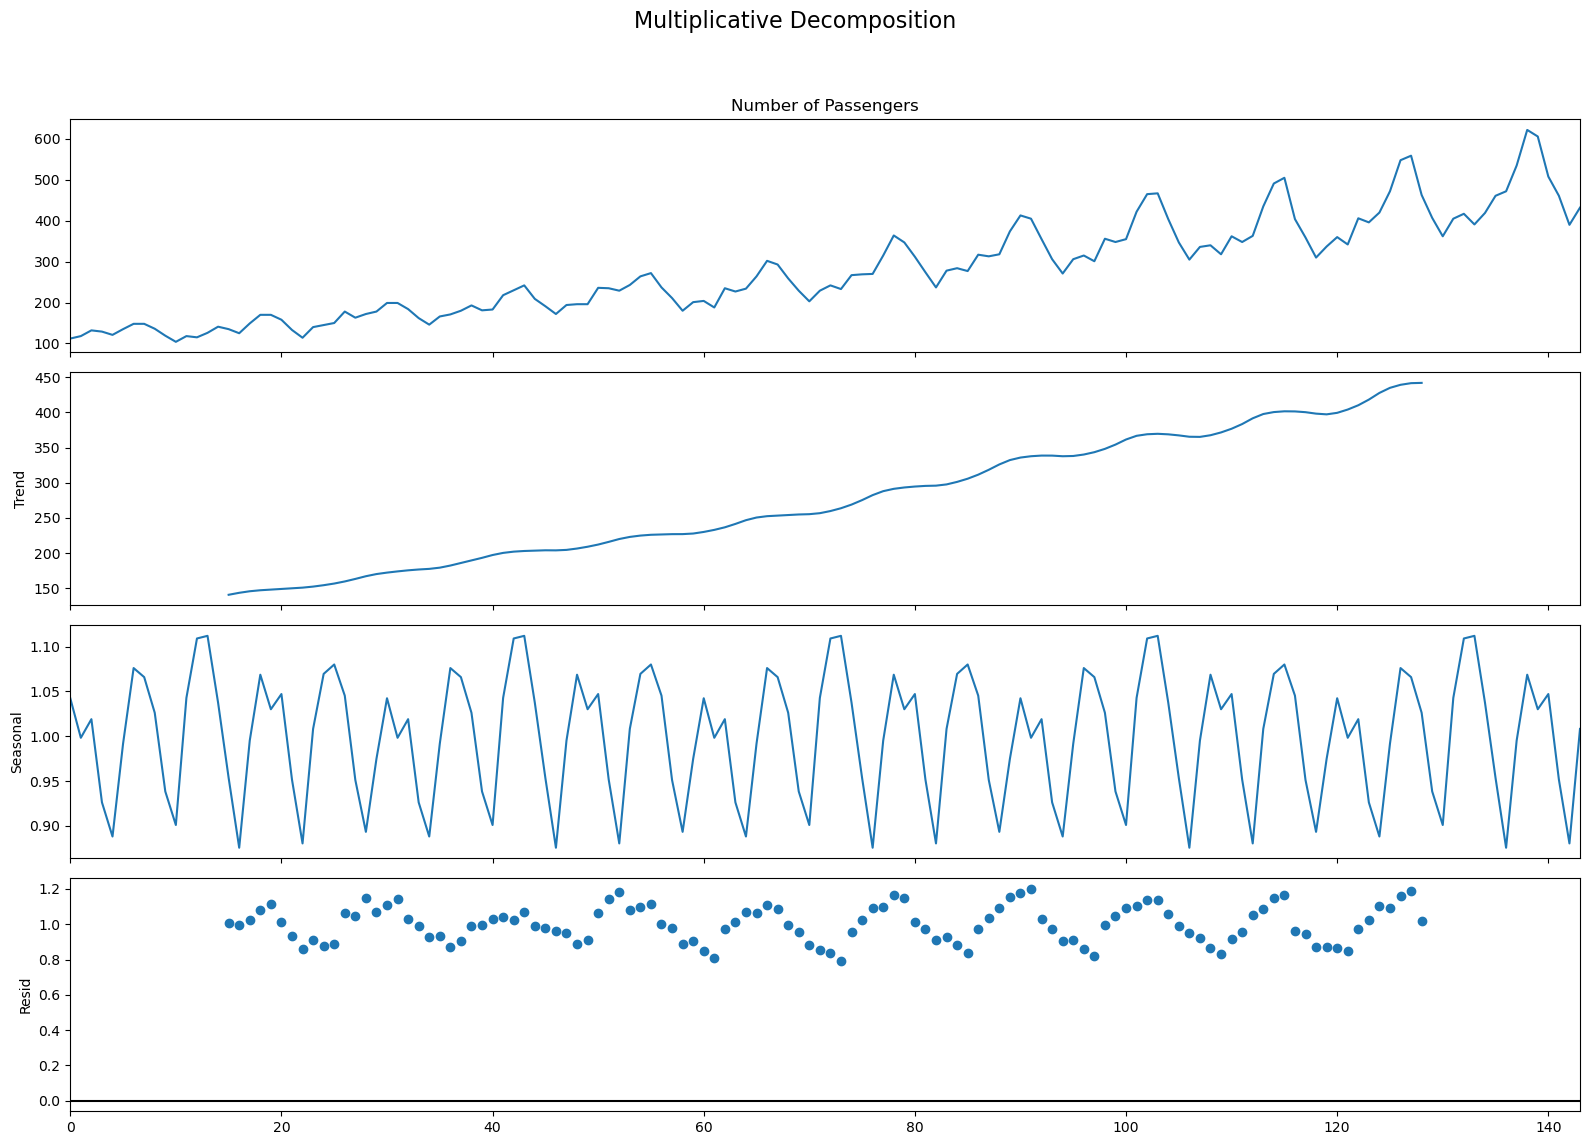

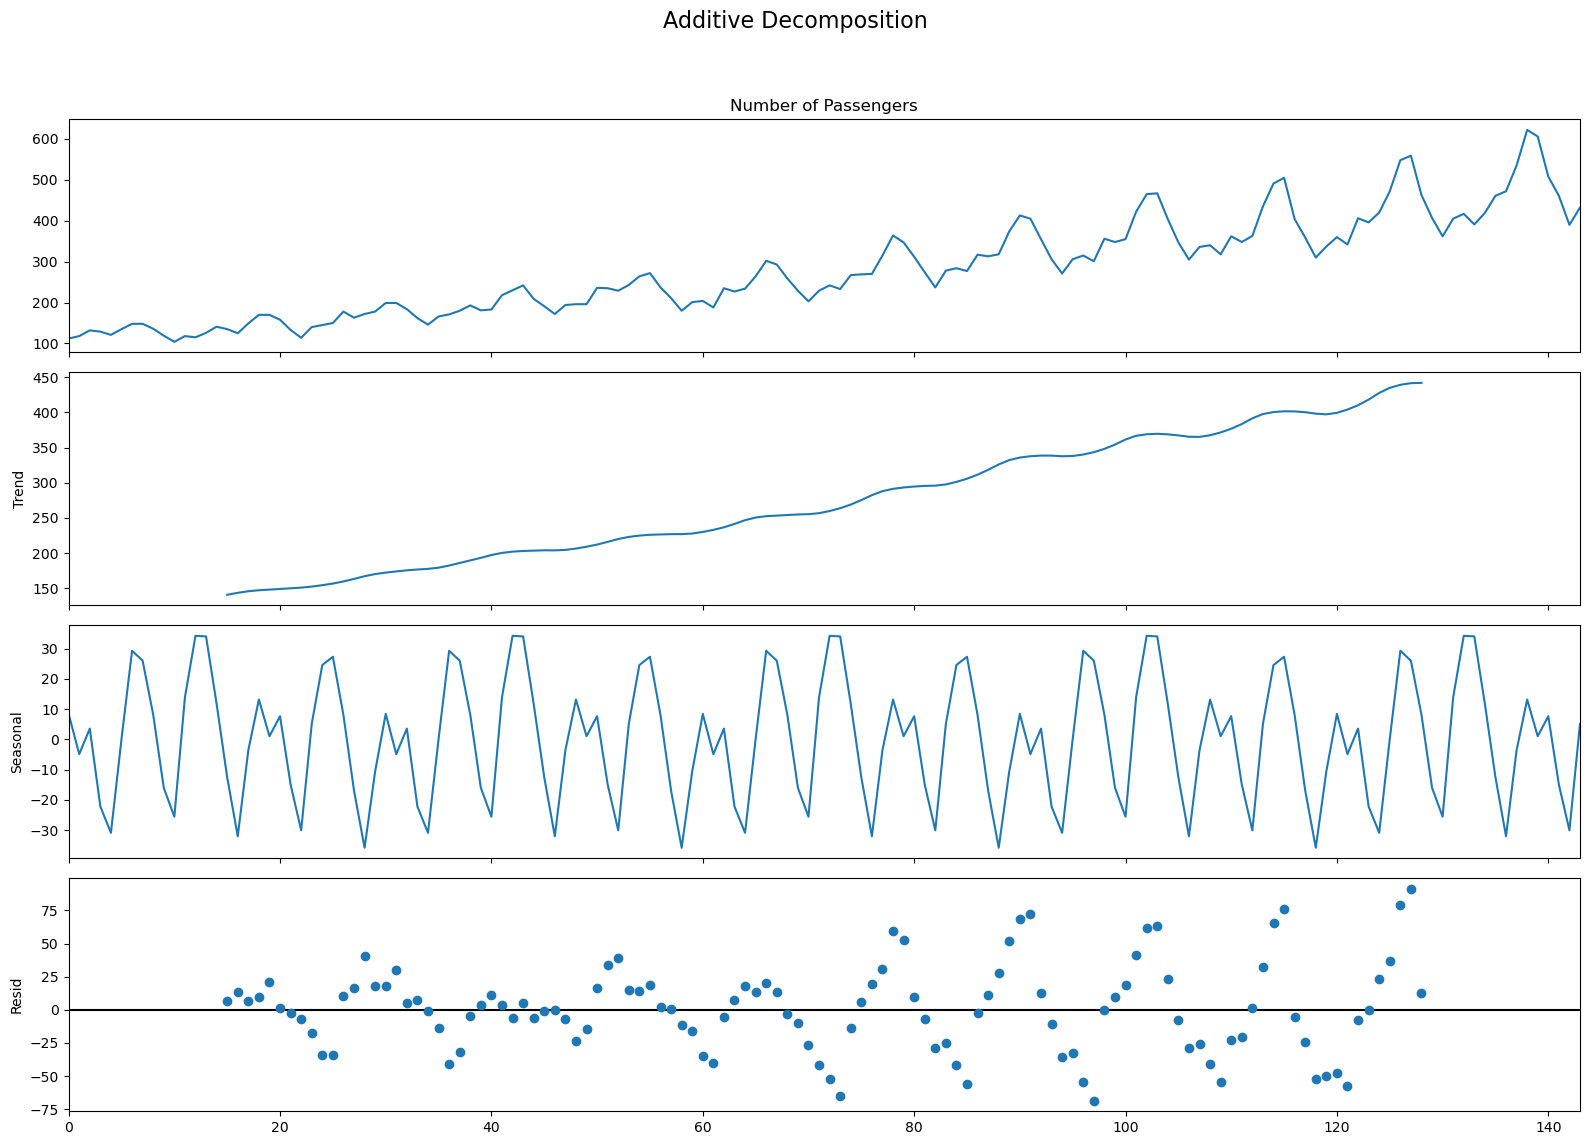

In [16]:
from statsmodels.tsa.seasonal import seasonal_decompose
from dateutil.parser import parse


# Multiplicative Decomposition 
multiplicative_decomposition = seasonal_decompose(data['Number of Passengers'], model='multiplicative', period=30)

# Additive Decomposition
additive_decomposition = seasonal_decompose(data['Number of Passengers'], model='additive', period=30)

# Plot
plt.rcParams.update({'figure.figsize': (16,12)})
multiplicative_decomposition.plot().suptitle('Multiplicative Decomposition', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

additive_decomposition.plot().suptitle('Additive Decomposition', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()

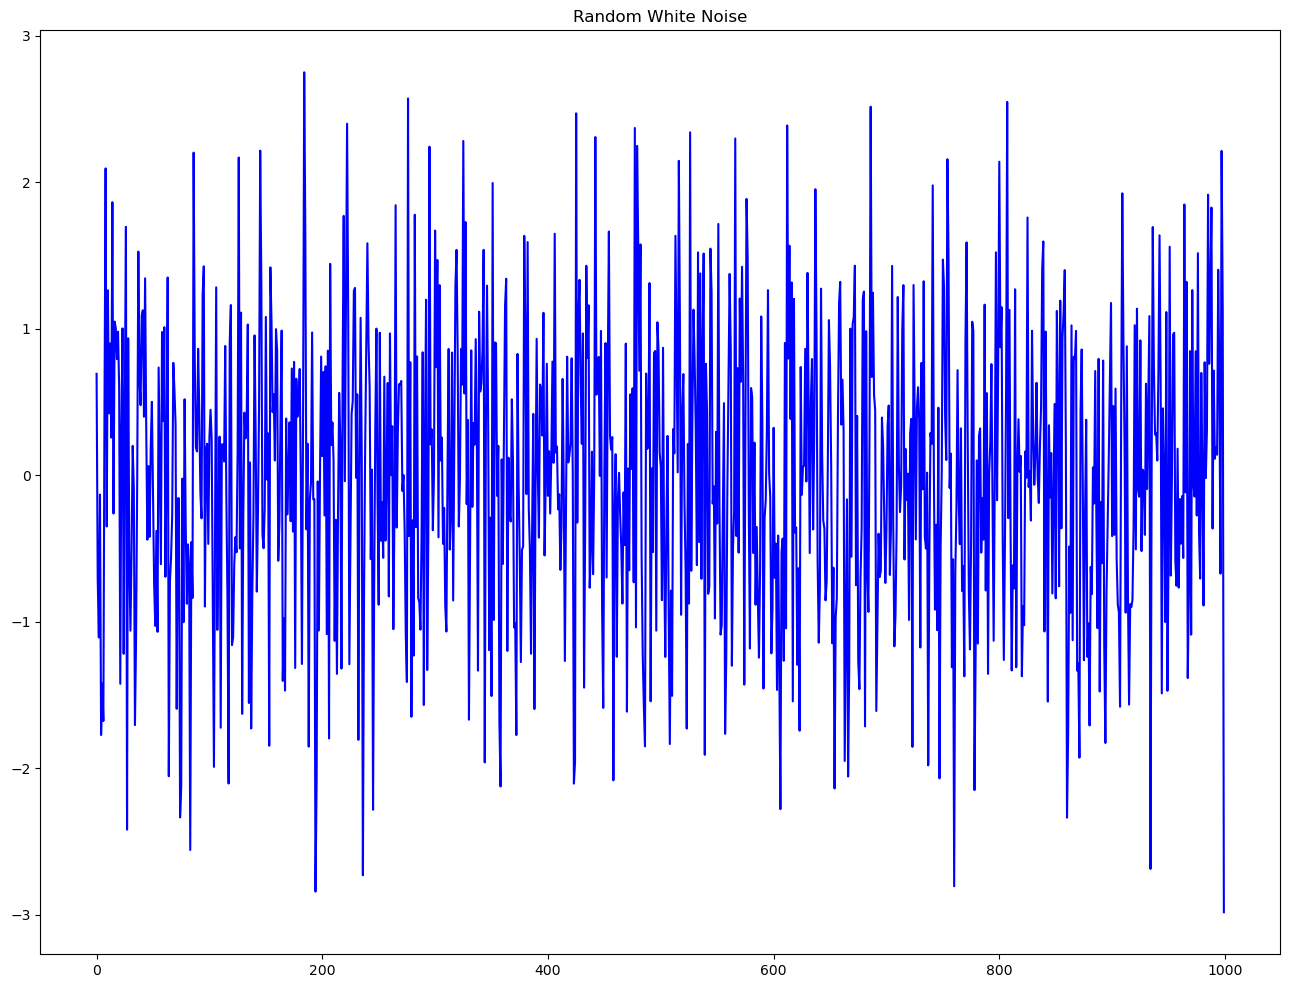

In [17]:
rand_numbers = np.random.randn(1000)
pd.Series(rand_numbers).plot(title='Random White Noise', color='b')
plt.show()

## Detrend A Time Series

Text(0.5, 1.0, 'Air Passengers detrended by subtracting the least squares fit')

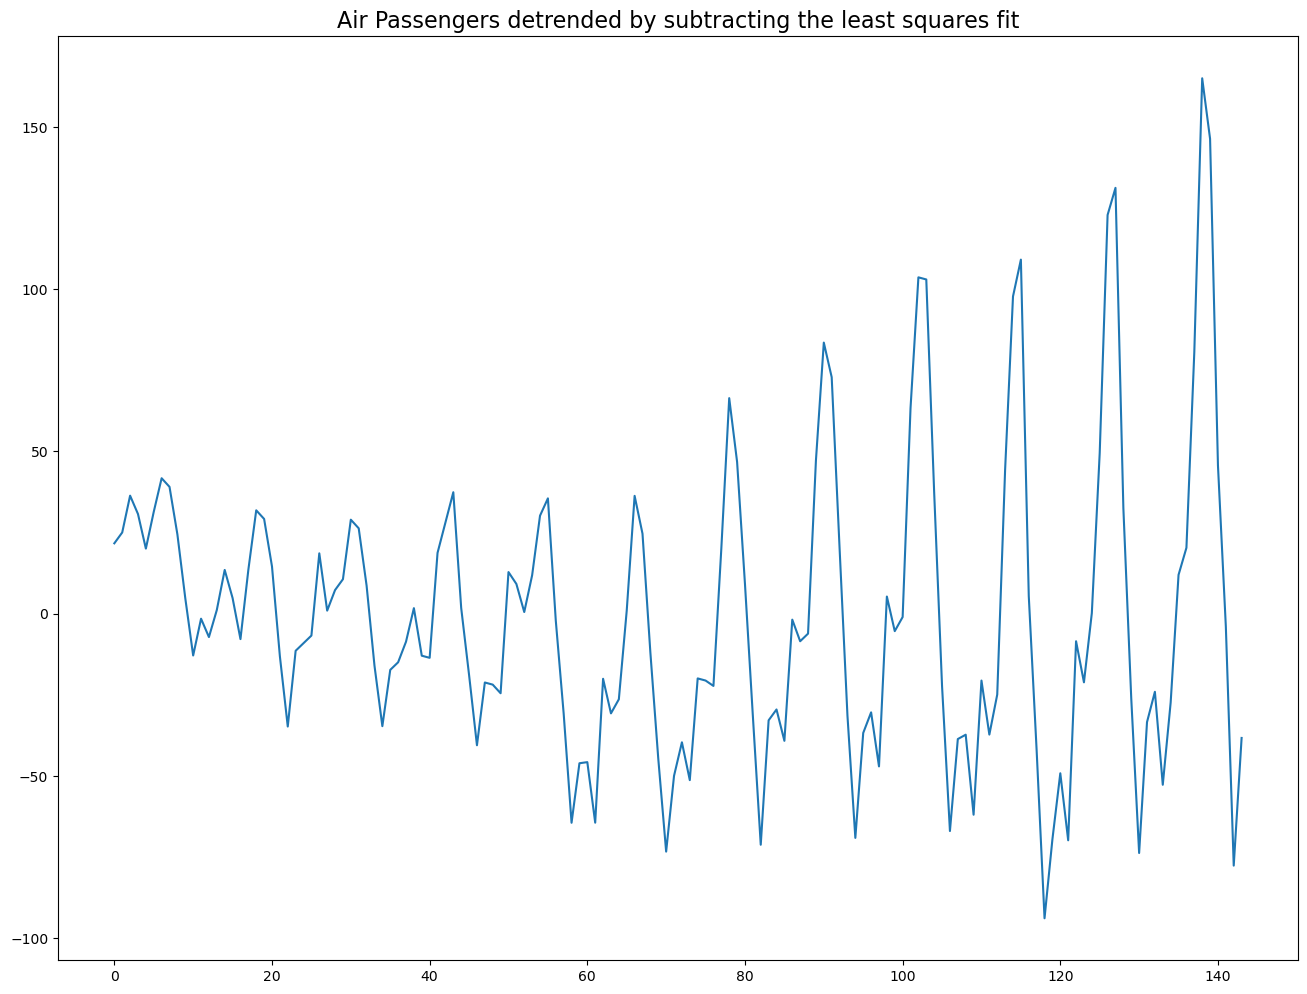

In [18]:
from scipy import signal
detrended = signal.detrend(data['Number of Passengers'].values)
plt.plot(detrended)
plt.title('Air Passengers detrended by subtracting the least squares fit', fontsize=16)

### Using statmodel

Text(0.5, 1.0, 'Air Passengers detrended by subtracting the trend component')

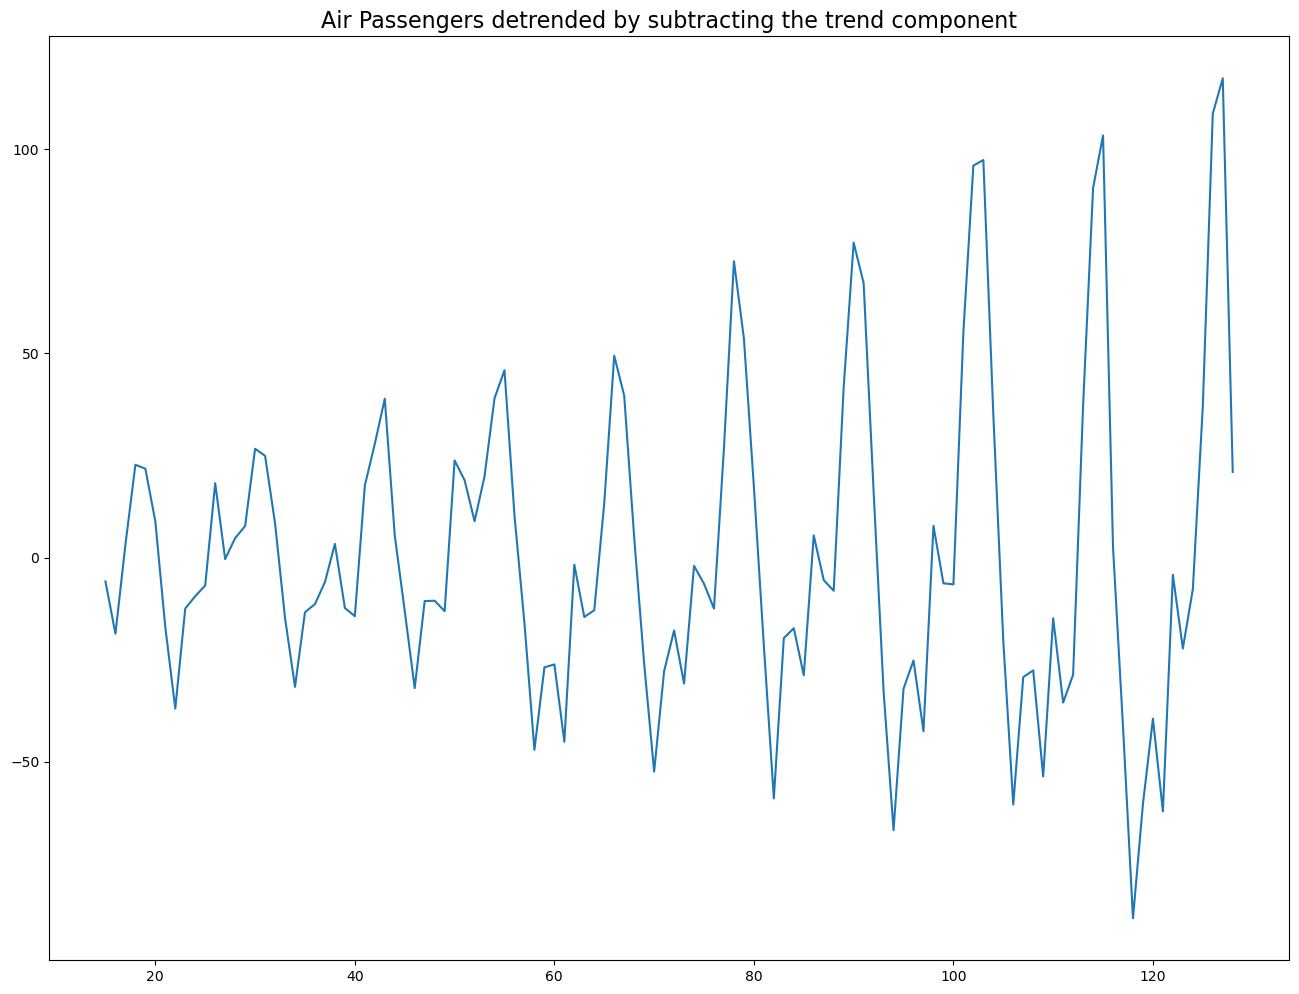

In [19]:
from statsmodels.tsa.seasonal import seasonal_decompose
result_mul = seasonal_decompose(data['Number of Passengers'], model='multiplicative', period=30)
detrended = data['Number of Passengers'].values - result_mul.trend
plt.plot(detrended)
plt.title('Air Passengers detrended by subtracting the trend component', fontsize=16)

## Deseasonalizing(subtracting) A Time Series

[]

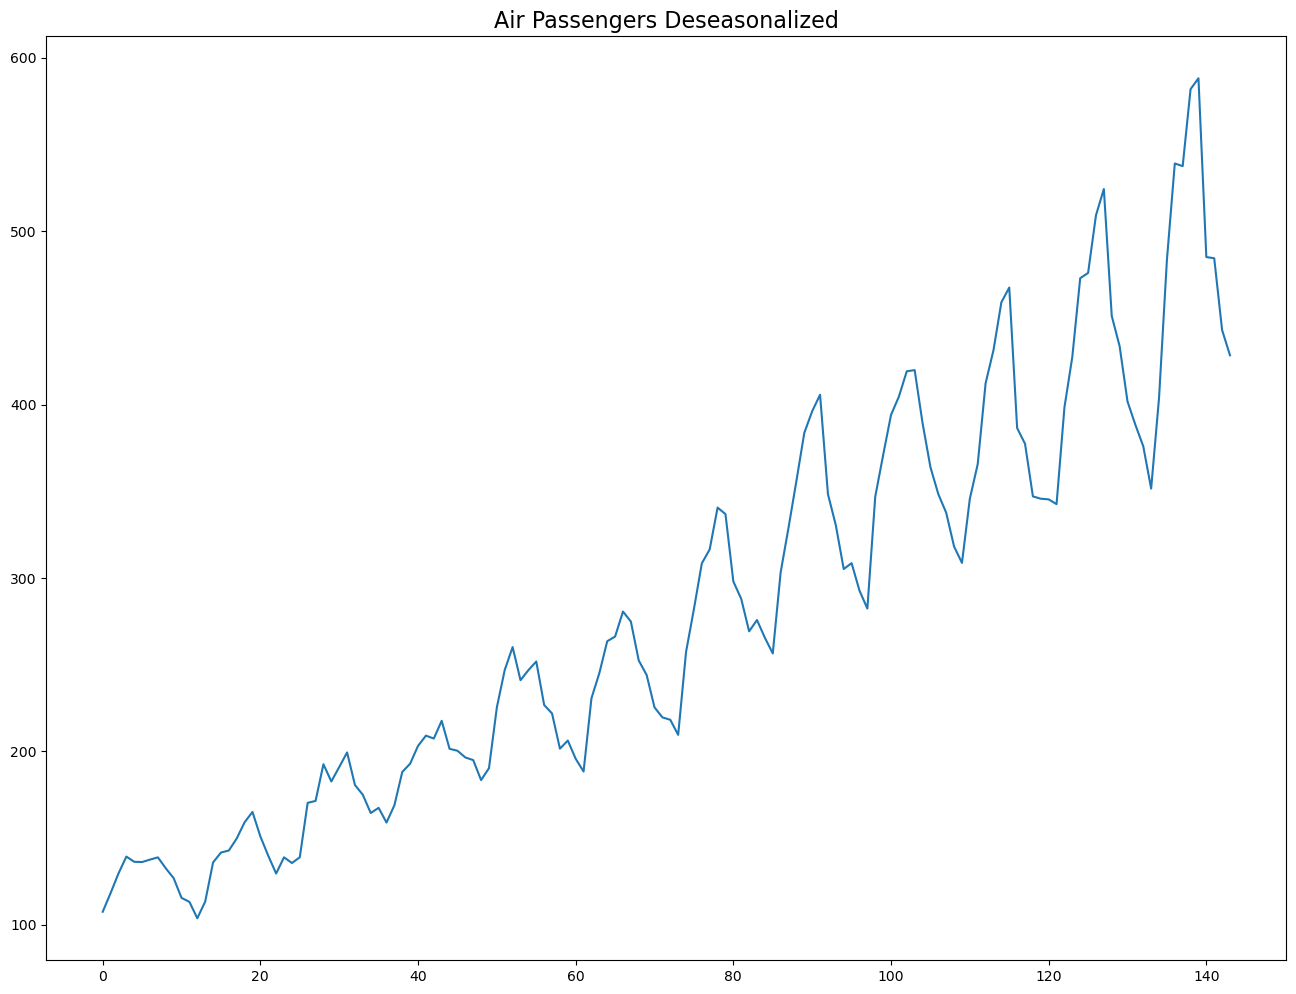

In [20]:
# Time Series Decomposition
result_mul = seasonal_decompose(data['Number of Passengers'], model='multiplicative', period=30)

# Deseasonalize
deseasonalized = data['Number of Passengers'].values / result_mul.seasonal

# Plot
plt.plot(deseasonalized)
plt.title('Air Passengers Deseasonalized', fontsize=16)
plt.plot()

### Test For Seasonality Of A Time Series

<Axes: xlabel='Lag', ylabel='Autocorrelation'>

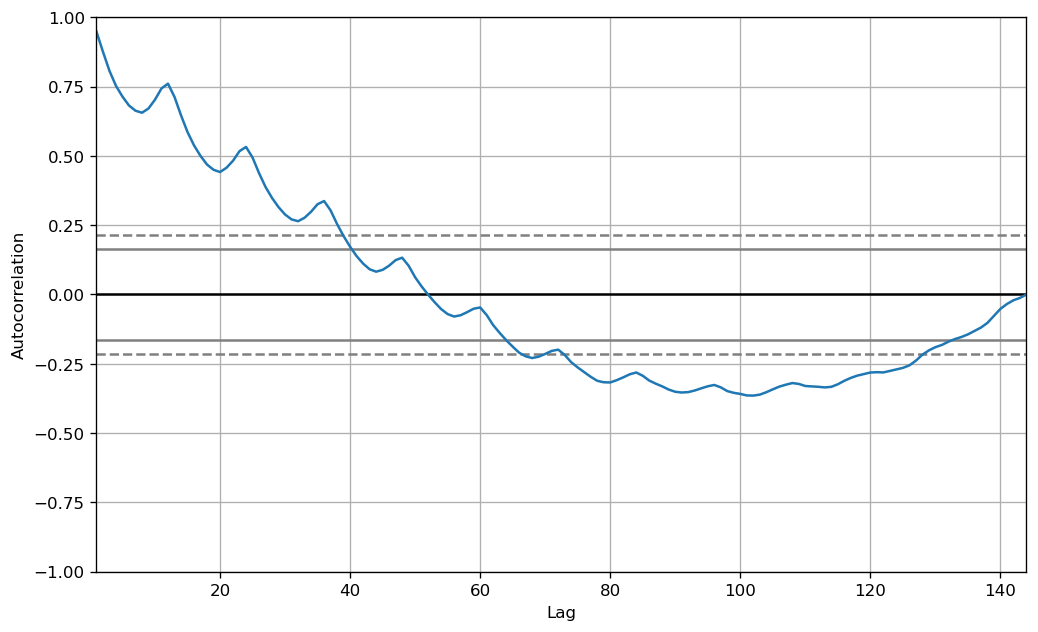

In [21]:
from pandas.plotting import autocorrelation_plot

plt.rcParams.update({'figure.figsize':(10,6), 'figure.dpi':120})
autocorrelation_plot(data['Number of Passengers'].tolist())

## Auto-Correlation & Partial-Correlation Function

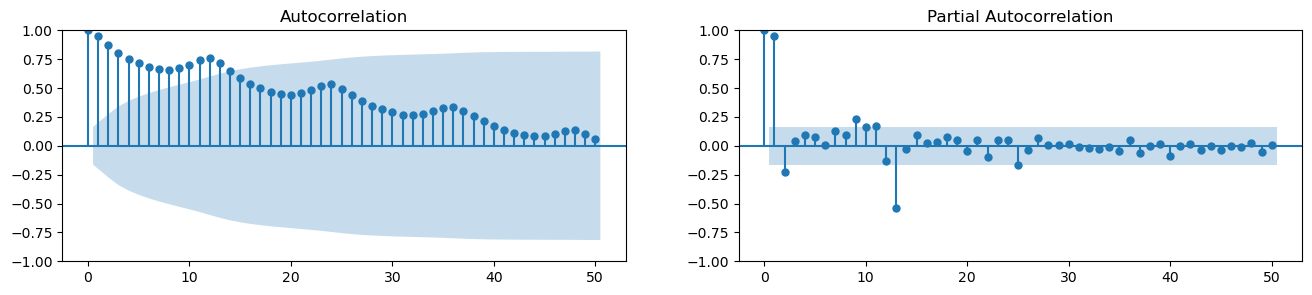

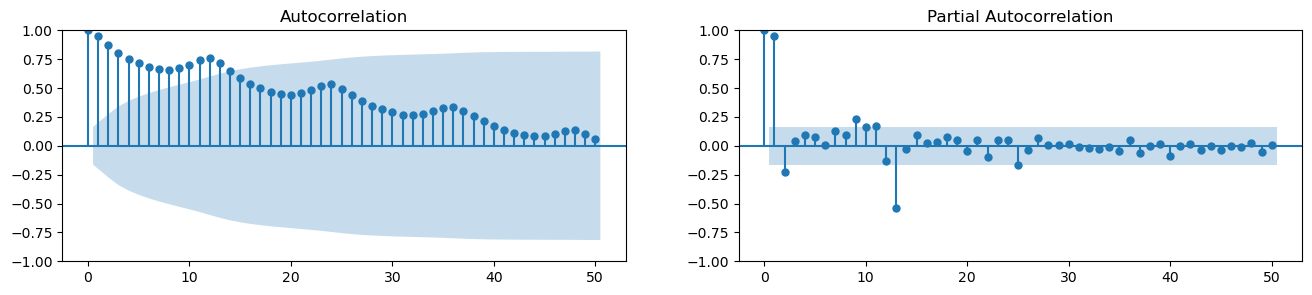

In [22]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1,2,figsize=(16,3), dpi= 100)
plot_acf(data['Number of Passengers'].tolist(), lags=50, ax=axes[0])
plot_pacf(data['Number of Passengers'].tolist(), lags=50, ax=axes[1])

## Lag Plots

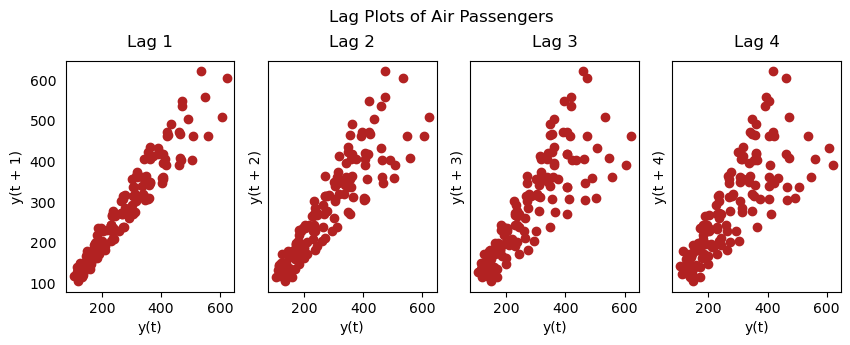

In [23]:
from pandas.plotting import lag_plot
plt.rcParams.update({'ytick.left' : False, 'axes.titlepad':10})

fig, axes = plt.subplots(1, 4, figsize=(10,3), sharex=True, sharey=True, dpi=100)
for i, ax in enumerate(axes.flatten()[:4]):
    lag_plot(data['Number of Passengers'], lag=i+1, ax=ax, c='firebrick')
    ax.set_title('Lag ' + str(i+1))

fig.suptitle('Lag Plots of Air Passengers', y=1.05)    
plt.show()